In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)

In [ ]:
df = pd.read_csv("/Users/ayushparoha/Downloads/sml/ass6/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [ ]:
print("Shape: ", df.shape)
print("Columns: ", list(df.columns))

Shape:  (1470, 35)
Columns:  ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
print(f"\nAttrition counts:\n{df['Attrition'].value_counts()}")
print(f"Attrition rate: {df['Attrition'].eq('Yes').mean():.1%} of employees")

print(f"\nMissing values: {df.isnull().sum().sum()}")


Attrition counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition rate: 16.1% of employees

Missing values: 0


In [ ]:
drop_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df = df.drop(columns=drop_cols)
print("Dropped constant/ID columns: ", drop_cols)

# Encode the target: Yes -> 1 (attrition), No -> 0 (stayed)
df["Attrition"] = LabelEncoder().fit_transform(df["Attrition"])

Dropped constant/ID columns:  ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']


In [ ]:
binary_cols = [c for c in df.select_dtypes(include="object").columns
               if df[c].nunique() == 2]
multi_cols = [c for c in df.select_dtypes(include="object").columns
              if df[c].nunique() > 2]

df_enc = df.copy()
le = LabelEncoder()
for col in binary_cols:
    df_enc[col] = le.fit_transform(df_enc[col])
    print(f"Label-encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_enc = pd.get_dummies(df_enc, columns=multi_cols, drop_first=True)
print("One-hot encoded: ", multi_cols)

X = df_enc.drop(columns="Attrition")
y = df_enc["Attrition"]
print("Feature matrix shape: ", X.shape)
print("Features: ", list(X.columns))

Label-encoded Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Label-encoded OverTime: {'No': np.int64(0), 'Yes': np.int64(1)}
One-hot encoded:  ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
Feature matrix shape:  (1470, 44)
Features:  ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Train attrition rate: {y_train.mean():.1%} | Test attrition rate: {y_test.mean():.1%}")


Train: (1176, 44) | Test: (294, 44)
Train attrition rate: 16.2% | Test attrition rate: 16.0%



Test accuracy: 82.65%
OOB score:     85.80%
(OOB and test accuracy being close means the model is not overfitting to the train split)

              precision    recall  f1-score   support

      Stayed       0.85      0.97      0.90       247
        Left       0.30      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.57      0.52      0.50       294
weighted avg       0.76      0.83      0.78       294



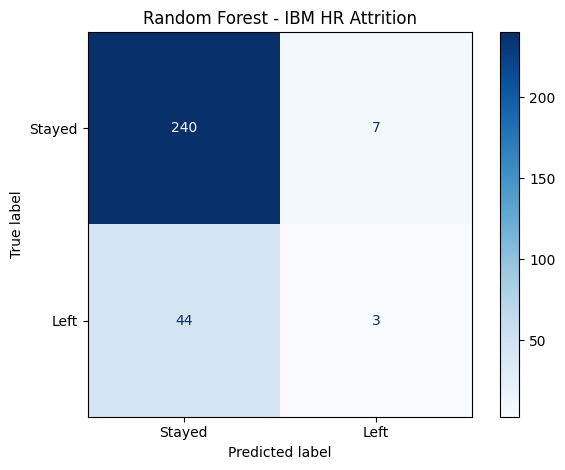

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"\nTest accuracy: {acc * 100:.2f}%")
print(f"OOB score:     {rf.oob_score_ * 100:.2f}%")
print("(OOB and test accuracy being close means the model is not overfitting to the train split)\n")

print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Stayed", "Left"], cmap="Blues"
)
plt.title("Random Forest - IBM HR Attrition")
plt.tight_layout()
plt.show()

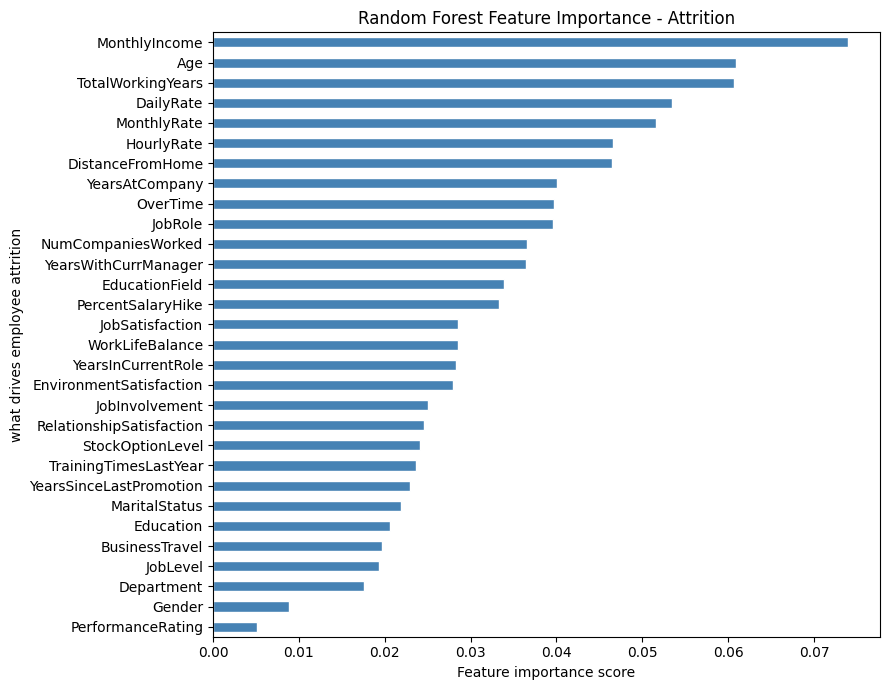

In [ ]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
original = {}
for col in X.columns:
    base = col
    for multi in multi_cols:
        if col.startswith(multi + "_"):
            base = multi
            break
    original[col] = base
grouped_importance = importance.groupby(original).sum().sort_values(ascending=False)

plt.figure(figsize=(9, 7))
grouped_importance.sort_values().plot(kind="barh", color="steelblue", edgecolor="white")
plt.xlabel("Feature importance score")
plt.ylabel("what drives employee attrition")
plt.title("Random Forest Feature Importance - Attrition")
plt.tight_layout()
plt.show()

In [ ]:
print("Top 10 features driving attrition: ")
print(grouped_importance.head(10).round(4))

print("""
Interpretation:
- OverTime is usually the single strongest driver: employees working
  overtime leave far more often.
- MonthlyIncome / StockOptionLevel / JobLevel / Age / TotalWorkingYears
  reflect pay and seniority - lower paid, junior and newer employees
  are the most likely leavers.
- JobRole, MaritalStatus and JobSatisfaction / EnvironmentSatisfaction
  add smaller but real contributions.
- Note that these are impurity-based importances: they favour
  high-cardinality and continuous features and can split credit between
  correlated variables, so the ordering is a guide rather than a cause.
""")

Top 10 features driving attrition: 
MonthlyIncome        0.0740
Age                  0.0609
TotalWorkingYears    0.0607
DailyRate            0.0534
MonthlyRate          0.0516
HourlyRate           0.0466
DistanceFromHome     0.0465
YearsAtCompany       0.0400
OverTime             0.0397
JobRole              0.0396
dtype: float64

Interpretation:
- OverTime is usually the single strongest driver: employees working
  overtime leave far more often.
- MonthlyIncome / StockOptionLevel / JobLevel / Age / TotalWorkingYears
  reflect pay and seniority - lower paid, junior and newer employees
  are the most likely leavers.
- JobRole, MaritalStatus and JobSatisfaction / EnvironmentSatisfaction
  add smaller but real contributions.
- Note that these are impurity-based importances: they favour
  high-cardinality and continuous features and can split credit between
  correlated variables, so the ordering is a guide rather than a cause.



/Users/ayushparoha/Downloads/sml/env/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


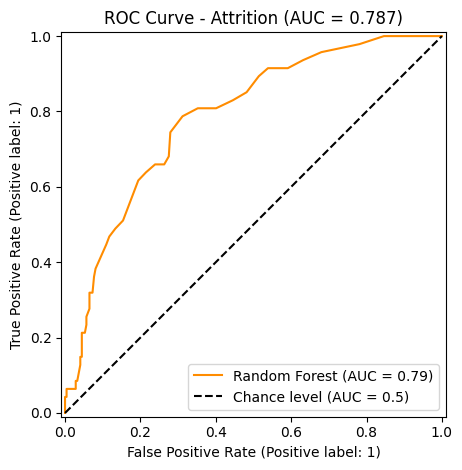

Accuracy: 0.8265
ROC-AUC:  0.7867


In [ ]:
auc = roc_auc_score(y_test, y_proba)
RocCurveDisplay.from_predictions(
    y_test, y_proba, color="darkorange", plot_chance_level=True, name="Random Forest"
)
plt.title(f"ROC Curve - Attrition (AUC = {auc:.3f})")
plt.tight_layout()
plt.show()

print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc:.4f}")

In [ ]:
print("""
Interpretation of the imbalance:
- Accuracy is misleading here: a model that always predicts "Stayed"
  would already score ~84% while catching zero leavers. That is why the
  recall on the "Left" class in the report above matters more.
- ROC-AUC (~0.78-0.82) measures ranking quality across all thresholds
  and is unaffected by the class ratio, so it is the fairer headline
  metric. A curve far above the diagonal is a genuinely useful model.
- The curve's steep initial rise means a high-recall operating point is
  reachable at the cost of precision, which suits HR: screening a wider
  list of at-risk employees is usually acceptable.
""")


Interpretation of the imbalance:
- Accuracy is misleading here: a model that always predicts "Stayed"
  would already score ~84% while catching zero leavers. That is why the
  recall on the "Left" class in the report above matters more.
- ROC-AUC (~0.78-0.82) measures ranking quality across all thresholds
  and is unaffected by the class ratio, so it is the fairer headline
  metric. A curve far above the diagonal is a genuinely useful model.
- The curve's steep initial rise means a high-recall operating point is
  reachable at the cost of precision, which suits HR: screening a wider
  list of at-risk employees is usually acceptable.



In [ ]:
rf_bal = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", oob_score=True,
    random_state=42, n_jobs=-1,
)
rf_bal.fit(X_train, y_train)
print(f"With class_weight='balanced' -> accuracy: {rf_bal.score(X_test, y_test):.4f}"
      f" | OOB: {rf_bal.oob_score_:.4f}"
      f" | AUC: {roc_auc_score(y_test, rf_bal.predict_proba(X_test)[:, 1]):.4f}")

With class_weight='balanced' -> accuracy: 0.8367 | OOB: 0.8571 | AUC: 0.7508


In [ ]:
n_trees = [1, 5, 10, 20, 50, 100, 200, 400]
train_accs, test_accs, oob_scores = [], [], []

for n in n_trees:
    clf = RandomForestClassifier(
        n_estimators=n, oob_score=True, random_state=42, n_jobs=-1
    ).fit(X_train, y_train)
    train_accs.append(clf.score(X_train, y_train) * 100)
    test_accs.append(clf.score(X_test, y_test) * 100)
    # With a single tree every row is in-bag, so no row has an
    # out-of-bag prediction and the OOB score is undefined (nan).
    oob_scores.append(clf.oob_score_ * 100)
    oob_txt = f"{oob_scores[-1]:6.2f}%" if np.isfinite(oob_scores[-1]) else "  n/a "
    print(f"n_estimators={n:4d} | train {train_accs[-1]:6.2f}% "
          f"| test {test_accs[-1]:6.2f}% | oob {oob_txt}")

/Users/ayushparoha/Downloads/sml/env/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/ayushparoha/Downloads/sml/env/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/ayushparoha/Downloads/sml/env/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/ayushparoha/Downloads/sml/env/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n_estimators=   1 | train  91.16% | test  76.53% | oob  80.87%
n_estimators=   5 | train  97.28% | test  82.99% | oob  80.95%
n_estimators=  10 | train  97.96% | test  84.35% | oob  82.14%
n_estimators=  20 | train  99.66% | test  84.01% | oob  83.76%
n_estimators=  50 | train 100.00% | test  83.33% | oob  85.12%
n_estimators= 100 | train 100.00% | test  82.65% | oob  85.80%
n_estimators= 200 | train 100.00% | test  82.99% | oob  85.80%
n_estimators= 400 | train 100.00% | test  83.33% | oob  85.88%


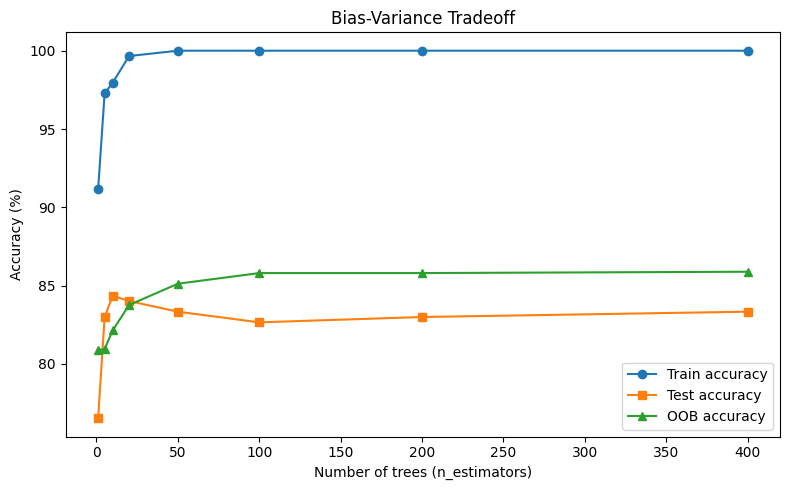

In [ ]:
valid = [i for i, s in enumerate(oob_scores) if np.isfinite(s)]

plt.figure(figsize=(8, 5))
plt.plot(n_trees, train_accs, marker="o", label="Train accuracy")
plt.plot(n_trees, test_accs, marker="s", label="Test accuracy")
plt.plot([n_trees[i] for i in valid], [oob_scores[i] for i in valid],
         marker="^", label="OOB accuracy")
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("Accuracy (%)")
plt.title("Bias-Variance Tradeoff")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("""
Interpretation:
- Train accuracy is always higher than test accuracy - that gap is the
  variance (overfitting) of the ensemble.
- With very few trees the test/OOB curve swings a lot and the gap is
  wide; adding trees shrinks the gap until the curve saturates.
- Accuracy never reaches 100%, which is the irreducible bias of the
  model - a forest cannot fix a signal that simply is not in the data.
- Beyond ~100-200 trees the gain is negligible, so more trees only cost
  time. This is the classic "more trees never hurts, but has diminishing
  returns" behaviour of bagging.
""")


Interpretation:
- Train accuracy is always higher than test accuracy - that gap is the
  variance (overfitting) of the ensemble.
- With very few trees the test/OOB curve swings a lot and the gap is
  wide; adding trees shrinks the gap until the curve saturates.
- Accuracy never reaches 100%, which is the irreducible bias of the
  model - a forest cannot fix a signal that simply is not in the data.
- Beyond ~100-200 trees the gain is negligible, so more trees only cost
  time. This is the classic "more trees never hurts, but has diminishing
  returns" behaviour of bagging.



In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_proba = dt.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Train Accuracy": [
        accuracy_score(y_train, dt.predict(X_train)),
        accuracy_score(y_train, rf.predict(X_train)),
    ],
    "Test Accuracy": [
        accuracy_score(y_test, dt.predict(X_test)),
        acc,
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, dt_proba),
        auc,
    ],
})
results[["Train Accuracy", "Test Accuracy", "ROC-AUC"]] = \
    results[["Train Accuracy", "Test Accuracy", "ROC-AUC"]].round(4)
print("\nSingle Decision Tree vs Random Forest:")
print(results.to_string(index=False))


Single Decision Tree vs Random Forest:
        Model  Train Accuracy  Test Accuracy  ROC-AUC
Decision Tree             1.0         0.7585   0.5979
Random Forest             1.0         0.8265   0.7867


/Users/ayushparoha/Downloads/sml/env/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/ayushparoha/Downloads/sml/env/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


<Figure size 700x600 with 0 Axes>

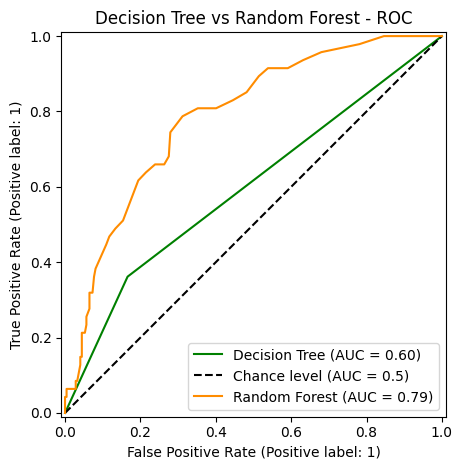

In [ ]:
plt.figure(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test, dt_proba, color="green", plot_chance_level=True, name="Decision Tree"
)
RocCurveDisplay.from_predictions(
    y_test, y_proba, color="darkorange", name="Random Forest", ax=plt.gca()
)
plt.title("Decision Tree vs Random Forest - ROC")
plt.tight_layout()
plt.show()

In [ ]:
print("""
Interpretation:
- The single tree scores ~100% on train but far lower on test: it grows
  until every leaf is pure, so it has high variance and memorises noise.
- The forest averages 100 de-correlated trees, so its train score drops
  slightly while test accuracy and especially AUC rise - bias goes up a
  little, variance goes down a lot.
- The AUC gap is the clearest evidence: the forest ranks at-risk
  employees much better than one tree, which is what matters for an
  imbalanced retention problem.
""")


Interpretation:
- The single tree scores ~100% on train but far lower on test: it grows
  until every leaf is pure, so it has high variance and memorises noise.
- The forest averages 100 de-correlated trees, so its train score drops
  slightly while test accuracy and especially AUC rise - bias goes up a
  little, variance goes down a lot.
- The AUC gap is the clearest evidence: the forest ranks at-risk
  employees much better than one tree, which is what matters for an
  imbalanced retention problem.

